In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import *

In [2]:
# Load dataset
ds = load_jsonl_file('./../datasets/MATE-dev/mm_0shot_llava_hfllava_1.5_7b_hf.jsonl')
nobjects=3

# Filter dataset for a specific number of objects 
ds_ = [data for data in ds if data['object_count'] == nobjects]

5500it [00:00, 8055.55it/s] 


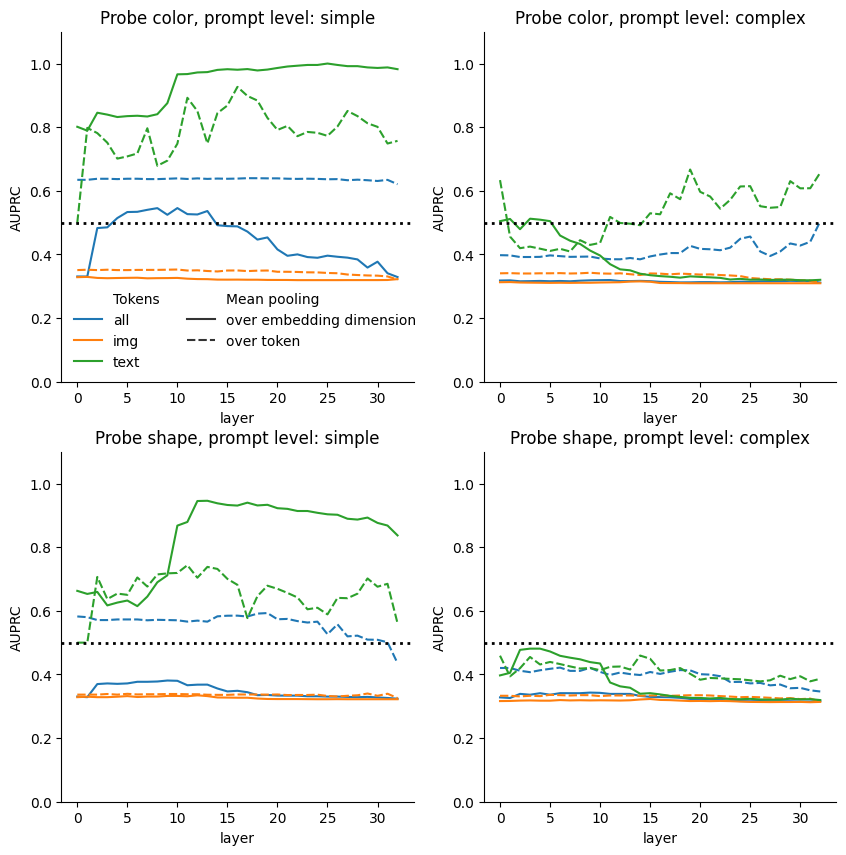

In [18]:
###### plot color probe results
tasks = ['color','shape']
metric = 'auprc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_balanced'  # 'image', 'text', 'image_balanced'
prompt_level=['simple', 'complex']
fig,axs = plt.subplots(len(tasks), len(prompt_level), figsize=(5*len(prompt_level), 5*len(tasks)))

for idx,task in enumerate(tasks): 
    for jdx, prompt_type in enumerate(prompt_level): 
        task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/{prompt_type}/probing_results_{task}_{nobjects}.csv", index_col=0) 

        task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
        task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
        task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]

        b = sns.lineplot(data=task_df,
                            x='layer', y=metric, hue='Tokens', style='Mean pooling',
                            ax=axs[idx][jdx])
                            # ax=axs[idx][jdx])
        baseline = 0.5

        b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
        b.set_title(f"Probe {task}, prompt level: {prompt_type}")
        b.set_ylabel(metric.upper())
        
        if idx == 0 and jdx==0:
            b.legend(frameon=False, ncols=2)
        else:
            b.legend_.remove()

        b.set(ylim=(0,1.1))

sns.despine(top=True, right=True)

TypeError: 'Axes' object is not subscriptable

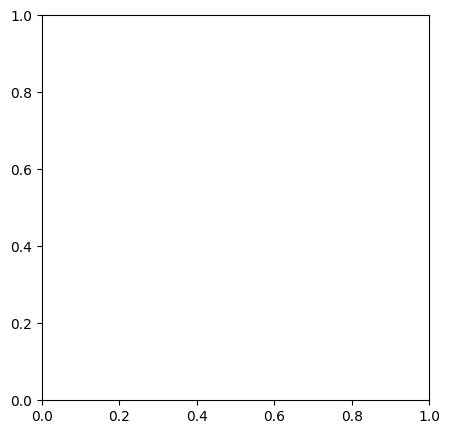

In [13]:
###### plot color probe results
tasks = ['color']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_balanced'  # 'image', 'text', 'image_balanced'
prompt_level=['simple', 'complex']
prompt_level=['complex']
fig,axs = plt.subplots(len(tasks), len(prompt_level), figsize=(5*len(prompt_level), 5*len(tasks)))

for idx,task in enumerate(tasks): 
    for jdx, prompt_type in enumerate(prompt_level): 
        task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/{prompt_type}/probing_results_{task}_{nobjects}.csv", index_col=0)
        vlm_results_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/{prompt_type}/vlm_results_{task}_{nobjects}.csv", index_col=0)   

        task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
        task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
        task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]

        b = sns.lineplot(data=task_df,
                            x='layer', y=metric, hue='Tokens', style='Mean pooling',
                            ax=axs[jdx])
                            # ax=axs[idx][jdx])
        baseline = 0.5

        b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
        b.axhline(y=vlm_results_df[metric].item(), color='red', linestyle=':', linewidth=2)
        b.set_title(f"Probe {task}, prompt level: {prompt_type}")
        b.set_ylabel(metric.upper())
        
        if idx == 0 and jdx==0:
            b.legend(frameon=False, ncols=2)
        else:
            b.legend_.remove()

        b.set(ylim=(0,1.1))

sns.despine(top=True, right=True)

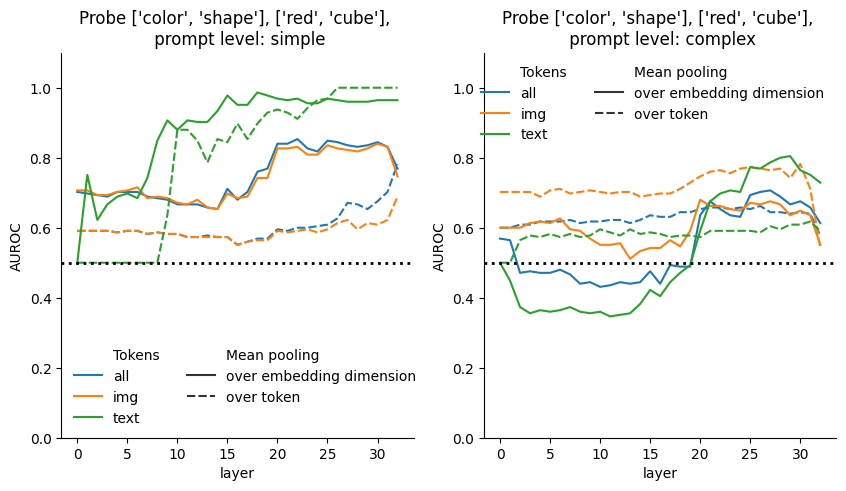

In [37]:

###### plot color probe results
tasks = ['color','shape']
targets = ['red', 'cube']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_2'  # 'image', 'text', 'image_balanced'
prompt_level=['simple', 'complex']

fig,axs = plt.subplots(1, 2, figsize=(5*len(prompt_level),5))

for jdx, prompt_type in enumerate(prompt_level):
    task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/{prompt_type}/probing_results_{tasks}_{targets}_{nobjects}.csv", index_col=0) 

    task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
    task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
    task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]
    # task_df = task_df[task_df['Mean pooling']=='over embedding dimension']

    b = sns.lineplot(data=task_df,
                        x='layer', y=metric, hue='Tokens', style='Mean pooling',
                        ax=axs[jdx])
                        # ax=axs[idx][jdx])
    baseline = 0.5

    b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
    b.set_title(f"Probe {tasks}, {targets}, \n prompt level: {prompt_type}")
    b.set_ylabel(metric.upper())
    b.legend(frameon=False, ncols=2)


    b.set(ylim=(0,1.1))

sns.despine(top=True, right=True)